In [1]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS, Isomap
import deep_sdf.workspace as ws
from sdf_utils import sap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import time

In [1]:
import torch
from sdf_utils import sap
import time
import random
import deep_sdf
from deep_sdf import mesh, metrics, lr_scheduling, plotting, utils, loss, data
import deep_sdf.workspace as ws
import json
import os
import reconstruct
import numpy as np
import matplotlib.pyplot as plt
import networks.sdf_vae as vae
import logging

In [2]:
def get_spec_with_default(specs, key, default):
    try:
        return specs[key]
    except KeyError:
        return default

In [3]:
#experiment_directory = "examples/torus/Run_w_con_loss_one_variable_usual"
experiment_directory = "examples/torus_subgroup/only_pointnet_deep_sdf_no_KL"
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
test_split_file = specs["TestSplit"]
train_split_file = specs["TrainSplit"]
data_source_mesh = specs["DataSourceMesh"]
with open(test_split_file, "r") as f:
    test_split = json.load(f)
eval_test_scene_num = get_spec_with_default(specs, "EvalTestSceneNumber", 10)
eval_test_optimization_steps = get_spec_with_default(specs, "EvalTestOptimizationSteps", 1000)
eval_grid_res = get_spec_with_default(specs, "EvalGridResolution", 256)
torus_path = get_spec_with_default(specs, "TorusPath", "/home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/scaled_obj_files")

In [4]:
# 2. Load the filenames of the meshes
with open(os.path.join(experiment_directory, "specs.json"), "r") as f:
    import json
    specs = json.load(f)
# Load all labels from the centralized label.pt file
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]
labels_path = os.path.join(data_source, "labels.pt")

# Load the split file to get filenames
with open(train_split_file, "r") as f:
    valid_filenames = json.load(f)

if os.path.exists(labels_path):
    print(f"Loading labels from {labels_path}")
    all_labels = torch.load(labels_path)
    print(f"All labels: {all_labels}")
    
    # Extract parameters for each filename
    mesh_params = []
    for filename in valid_filenames:
        # Extract base name without extension to match with label dict key
        base_name = os.path.splitext(os.path.basename(filename))[0]
        print(f"Base name: {base_name}")
        params = {}
        if base_name in all_labels:
            label = all_labels[base_name]
            params["has_bump"] = int(label[0].item())  # bump info at index 0
            params["scale"] = float(label[2].item())   # scale info at index 2
            params["bump_size"] = float(label[3].item())
            params["subgroup"] = int(label[4].item())
            #print(f"Label for {base_name}: {params}")
        else:
            print(f"Warning: No label found for {base_name}")
            params["has_bump"] = 0
            params["scale"] = 0.0
            params["bump_size"] = 0.0    
            params["subgroup"] = 0    
        mesh_params.append(params)

Loading labels from /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/labels.pt
All labels: {'torus_bump_0000': array([0.        , 1.        , 0.77926421, 0.64882943, 1.        ]), 'torus_bump_0001': array([1.        , 1.        , 0.26086957, 0.33779264, 1.        ]), 'torus_bump_0002': array([0.        , 1.        , 0.43812709, 0.54849498, 1.        ]), 'torus_bump_0003': array([1.        , 1.        , 0.03344482, 0.45819398, 1.        ]), 'torus_bump_0004': array([0.        , 1.        , 0.79598662, 0.17056856, 1.        ]), 'torus_bump_0005': array([1.        , 1.        , 0.60200669, 0.74247492, 1.        ]), 'torus_bump_0006': array([0.        , 1.        , 0.86956522, 0.11371237, 1.        ]), 'torus_bump_0007': array([1.        , 1.        , 0.13712375, 0.17391304, 1.        ]), 'torus_bump_0008': array([0.        , 1.        , 0.20401338, 0.75585284, 1.        ]), 'torus_bump_0009': array([1.   

In [5]:
# Extract parameters for visualization
has_bump = np.array([p.get("has_bump", 0) for p in mesh_params])
scales = np.array([p.get("scale", 0.0) for p in mesh_params])
bump_sizes = np.array([p.get("bump_size", 0.0) for p in mesh_params])
subgroups = np.array([p.get("subgroup", 0) for p in mesh_params])

# Create ground truth factors array for SAP calculation
ground_truth_factors = np.column_stack((has_bump, scales, bump_sizes, subgroups))
factor_names = ["bump", "scale", "bump_size", "subgroup"]

In [27]:
bump_sizes

array([0.13712375, 0.87625418, 0.6722408 , 0.15719064, 0.35785953,
       0.5819398 , 0.909699  , 0.76923077, 0.59197324, 0.909699  ,
       0.97993311, 0.4916388 , 0.8729097 , 0.51170569, 0.80602007,
       0.26086957, 0.7458194 , 0.85284281, 0.24414716, 0.15719064,
       0.36789298, 0.53177258, 0.01672241, 0.37792642, 0.51839465,
       0.18729097, 0.28428094, 0.09364548, 0.40802676, 0.86287625,
       0.84949833, 0.26086957, 0.77926421, 0.51839465, 0.44147157,
       0.24414716, 0.44816054, 0.65886288, 0.54180602, 0.05685619,
       0.32441472, 0.71906355, 0.57859532, 0.60869565, 0.89966555,
       0.82274247, 0.79598662, 0.71906355, 0.43143813, 0.48160535,
       0.15050167, 0.18394649, 0.68896321, 0.23745819, 0.6722408 ,
       0.16722408, 0.27424749, 0.32441472, 0.47157191, 0.17056856,
       0.91304348, 0.5451505 , 0.86287625, 0.46488294, 0.91973244,
       0.5819398 , 0.52173913, 0.51505017, 0.40468227, 0.06020067,
       0.21070234, 0.15719064, 0.61204013, 0.22742475, 0.95317

In [6]:
# 3. Apply various dimensionality reduction and factor analysis techniques
plt.figure(figsize=(20, 16))
results = {}
transformed_latents = {}
distances_all = []


<Figure size 2000x1600 with 0 Axes>

In [7]:
arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

#decoder = arch.Decoder(latent_size, **specs["NetworkSpecs"])
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
#decoder = torch.nn.DataParallel(decoder)

saved_model_state = torch.load(
    os.path.join(
        experiment_directory, ws.model_params_subdir, "latest" + ".pth"
    )
)
saved_model_epoch = saved_model_state["epoch"]

decoder.load_state_dict(saved_model_state["model_state_dict"])
#decoder = decoder.module.cuda()
decoder.eval()

SDFVAE(
  (encoder): DataParallel(
    (module): ResnetPointnet(
      (fc_pos): Linear(in_features=3, out_features=256, bias=True)
      (block_0): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_1): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_2): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_3): ResnetBlockFC(
        

In [8]:
eval_test_time_start = time.time()
test_err_sum = 0.
chamfer_dists = []
chamfer_dists_all = []
test_loss_hists = []
mesh_label_names = []
test_latents = []
sap_scores = []
all_labels = []
all_labels_reg = []
all_labels_group = []
all_latents = []

In [10]:
with open(train_split_file, "r") as f:
    train_split = json.load(f)

In [11]:
#eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, test_split)
eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, train_split)
labels = torch.load(data_source + "/labels.pt")
#eval_test_filenames = random.sample(eval_test_filenames, max(eval_test_scene_num, len(eval_test_filenames)))

In [12]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[0])
    all_labels_reg.append(label[2])
    all_labels_group.append(label[4])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "all_unsupervised", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)
        
    test_fpath = os.path.join(data_source, ws.sdf_samples_subdir, test_fname)
    test_sdf_samples = deep_sdf.data.read_sdf_samples_into_ram(test_fpath)
    test_sdf_samples[0] = test_sdf_samples[0][torch.randperm(test_sdf_samples[0].shape[0])]
    test_sdf_samples[1] = test_sdf_samples[1][torch.randperm(test_sdf_samples[1].shape[0])]
 
    print(f"Creating mesh for {test_fname}...")
    test_latent = None
    start = time.time()
    with torch.no_grad():
        test_mesh, z = mesh.create_mesh(
            decoder, 
            kl_div_loss,
            test_surface_points,
            test_latent, 
            N=eval_grid_res, 
            max_batch=int(2 ** 18), 
            filename=os.path.join(path, f"epoch={saved_model_epoch}"),
            return_trimesh=True,
            return_latent=True
        )
    print(f"Mesh creation for {test_fname} took {time.time()-start} seconds.")

    all_latents.append(z)

    if test_mesh is not None:
        gt_mesh_path = f"{torus_path}/{save_name}.obj"
        cd, cd_all = metrics.compute_metric(gt_mesh=gt_mesh_path, gen_mesh=test_mesh, metric="chamfer")
        chamfer_dists.append(cd)
        chamfer_dists_all.append(cd_all)

        del test_sdf_samples, test_mesh

Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_0505.npz took 8.05814266204834 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3796.npz took 5.402476787567139 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/sdf_data/SdfSamples/scaled_obj_files/torus_bump_4084.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bum

KeyboardInterrupt: 

In [17]:
# Create a directory to store the metrics
metrics_dir = os.path.join(experiment_directory, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Save the aggregated Chamfer distances
chamfer_path = os.path.join(metrics_dir, "chamfer_dists.npy")
np.save(chamfer_path, np.array(chamfer_dists))
print(f"Saved aggregated Chamfer distances to {chamfer_path}")

# Save the detailed point-wise Chamfer distances
chamfer_all_path = os.path.join(metrics_dir, "chamfer_dists_all.npy")
np.save(chamfer_all_path, np.array(chamfer_dists_all, dtype=object))
print(f"Saved detailed Chamfer distances to {chamfer_all_path}")

# Save the mapping between mesh names and their Chamfer distances
mesh_chamfer_mapping = {name: dist for name, dist in zip(mesh_label_names, chamfer_dists)}
with open(os.path.join(metrics_dir, "mesh_chamfer_mapping.json"), 'w') as f:
    json.dump(mesh_chamfer_mapping, f, indent=4)
print(f"Saved mesh to Chamfer distance mapping")

# Save all latents
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.stack([l.detach().cpu().numpy() for l in all_latents], axis=0)
np.save(latents_path, all_latents_array)
print(f"Saved all latents to {latents_path}")

Saved aggregated Chamfer distances to examples/torus_subgroup/metrics/chamfer_dists.npy
Saved detailed Chamfer distances to examples/torus_subgroup/metrics/chamfer_dists_all.npy
Saved mesh to Chamfer distance mapping
Saved all latents to examples/torus_subgroup/metrics/all_latents.npy


In [12]:
metrics_dir = os.path.join(experiment_directory, "metrics")
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.load(latents_path)
print(f"Shape of all latents: {all_latents_array.shape}")

Shape of all latents: (400, 1, 16)


In [14]:
all_latents_array = all_latents_array.squeeze()
X = all_latents_array

In [15]:
X.shape

(400, 16)

In [16]:
# ICA with 8 components - correlation analysis with all labels

import numpy as np
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply ICA with exactly 8 components
print("Applying ICA with 8 components...")
ica_8 = FastICA(n_components=8, random_state=42, max_iter=2000, tol=1e-6)
Y_ica_8 = ica_8.fit_transform(X_scaled)

print(f"ICA 8-component shape: {Y_ica_8.shape}")
print("\n" + "="*70)
print("ICA 8-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS")
print("="*70)

# Create mask for samples with bumps
samples_with_bump = has_bump == 1
n_bump_samples = np.sum(samples_with_bump)
print(f"\nTotal samples: {len(has_bump)}")
print(f"Samples with bumps: {n_bump_samples}")
print(f"Samples without bumps: {len(has_bump) - n_bump_samples}")

# Define labels for correlation
labels_dict_8comp = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Correlation matrix: rows = components, columns = labels
correlation_matrix_8 = np.zeros((8, len(labels_dict_8comp)))
label_names_8 = list(labels_dict_8comp.keys())

# Calculate correlations for each component with each label
for comp_idx in range(8):
    print(f"\nComponent {comp_idx+1}:")
    for label_idx, (label_name, label_data) in enumerate(labels_dict_8comp.items()):
        # Special handling: ONLY bump_sizes is conditional on bump=1
        if label_name == 'bump_sizes':
            if n_bump_samples > 1:
                corr = np.corrcoef(Y_ica_8[samples_with_bump, comp_idx], 
                                  label_data[samples_with_bump])[0, 1]
                correlation_matrix_8[comp_idx, label_idx] = corr
                print(f"  Correlation with {label_name:12s} (bump=1 only, n={n_bump_samples}): {corr:+.4f}")
            else:
                correlation_matrix_8[comp_idx, label_idx] = 0.0
                print(f"  Correlation with {label_name:12s}: N/A (insufficient samples)")
        else:
            # Regular correlation for has_bump, scales, and subgroups (use ALL samples)
            corr = np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1]
            correlation_matrix_8[comp_idx, label_idx] = corr
            print(f"  Correlation with {label_name:12s}: {corr:+.4f}")

# Find best component for each label
print("\n" + "="*70)
print("BEST COMPONENT FOR EACH LABEL:")
print("="*70)
for label_idx, label_name in enumerate(label_names_8):
    abs_corrs = np.abs(correlation_matrix_8[:, label_idx])
    best_comp = np.argmax(abs_corrs)
    best_corr = correlation_matrix_8[best_comp, label_idx]
    
    if label_name == 'bump_sizes':
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f}) [bump=1 only]")
    else:
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f})")

# Store results
results["ICA_8"] = Y_ica_8
transformed_latents["ICA_8"] = Y_ica_8

print("\n✅ ICA with 8 components completed!")
print(f"✅ Results stored in results['ICA_8'] and transformed_latents['ICA_8']")
print(f"✅ Correlation analysis completed!")
print(f"   - has_bump, scales & subgroups: ALL samples")
print(f"   - bump_sizes: ONLY bump=1 samples")

Applying ICA with 8 components...
ICA 8-component shape: (400, 8)

ICA 8-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS

Total samples: 400
Samples with bumps: 200
Samples without bumps: 200

Component 1:
  Correlation with has_bump    : +0.0308
  Correlation with scales      : +0.1166
  Correlation with bump_sizes   (bump=1 only, n=200): -0.1872
  Correlation with subgroups   : -0.0036

Component 2:
  Correlation with has_bump    : -0.0612
  Correlation with scales      : -0.9054
  Correlation with bump_sizes   (bump=1 only, n=200): -0.0745
  Correlation with subgroups   : +0.0122

Component 3:
  Correlation with has_bump    : -0.0439
  Correlation with scales      : -0.0247
  Correlation with bump_sizes   (bump=1 only, n=200): -0.2051
  Correlation with subgroups   : +0.0217

Component 4:
  Correlation with has_bump    : +0.9161
  Correlation with scales      : +0.0502
  Correlation with bump_sizes   (bump=1 only, n=200): +0.8391
  Correlation with subgroups   : +0.0064

Component 5:

Best components selected for each property:
  has_bump: Component 4 (|corr| = 0.9161)
  scales: Component 2 (|corr| = 0.9054)
  bump_sizes: Component 4 (|corr| = 0.8391)
  subgroups: Component 7 (|corr| = 0.9542)

✅ Plots saved as 'ICA_factor_analysis_2x2.png' and '.pdf'


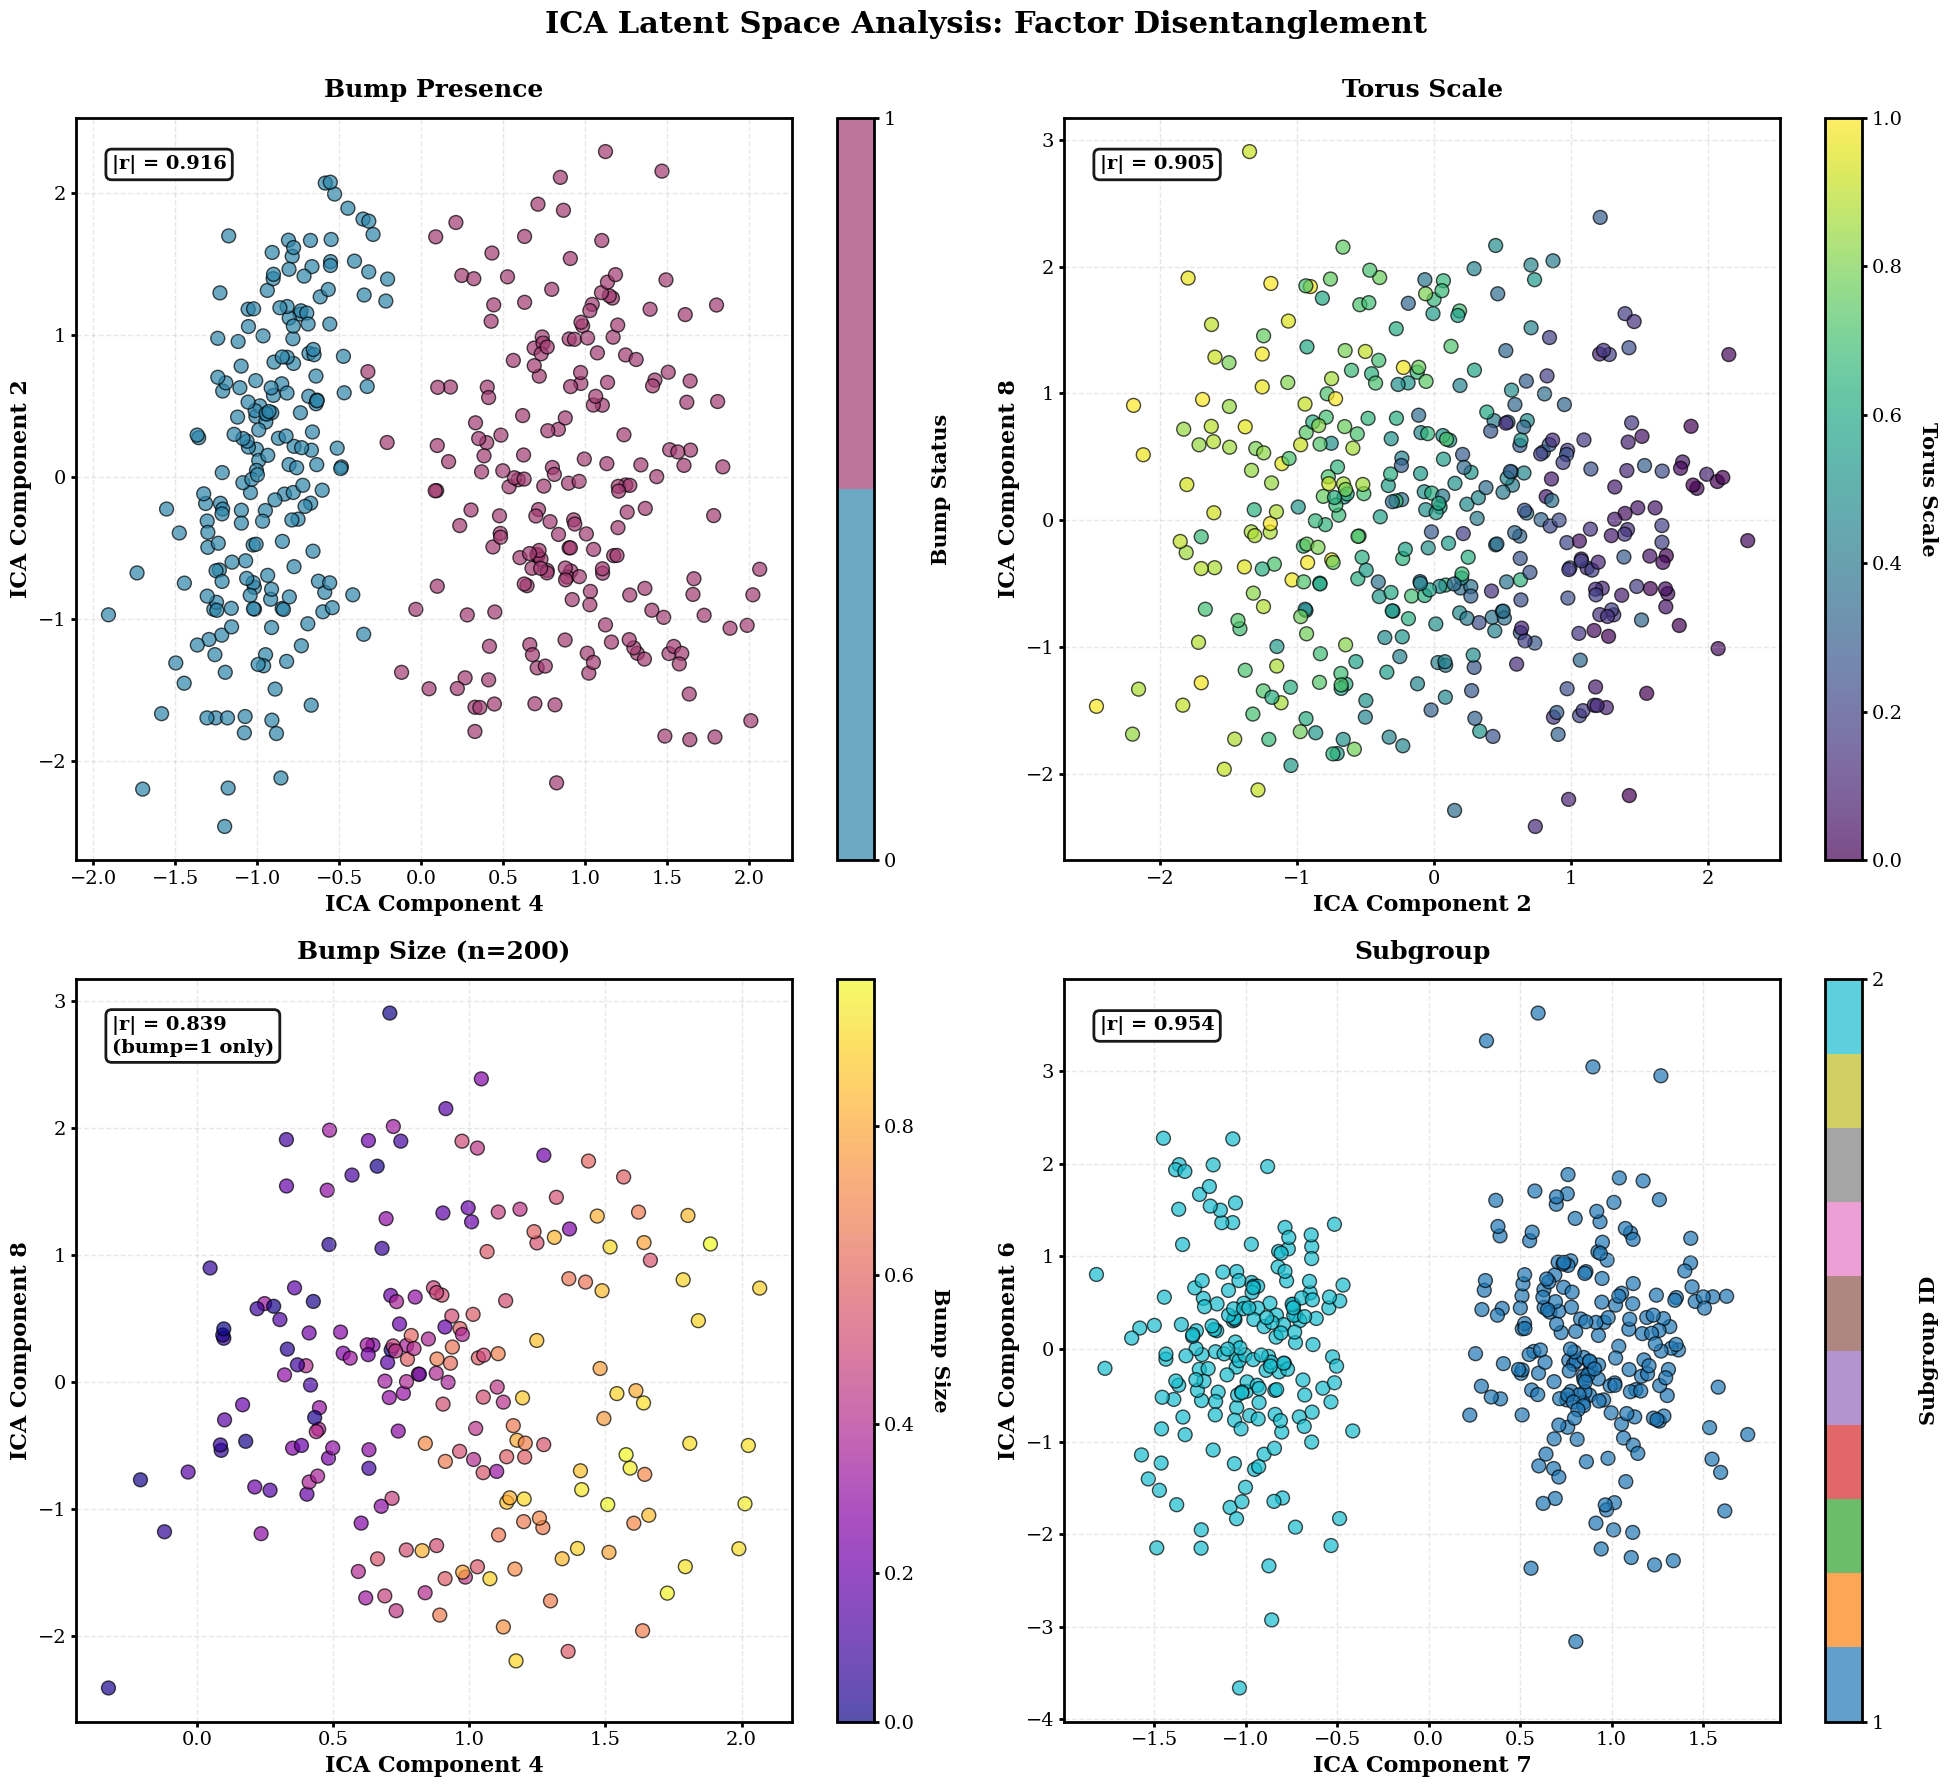


SUMMARY FOR DOCUMENTATION:

Bump Presence:
  Primary Component: ICA Component 4
  Correlation: |r| = 0.9161

Torus Scale:
  Primary Component: ICA Component 2
  Correlation: |r| = 0.9054

Bump Size (bump=1 only):
  Primary Component: ICA Component 4
  Correlation: |r| = 0.8391
  Samples plotted: 200 (only where bump=1)

Subgroup:
  Primary Component: ICA Component 7
  Correlation: |r| = 0.9542


In [17]:
# Professional Publication-Ready Plots for ICA 8 Components
# 2x2 layout with larger text for better visibility

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes for each property (professional/standard schemes)
color_schemes = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),  # Blue (no bump), Red (bump)
        'label': 'Bump Presence',
        'ticks': [0, 1],
        'tick_labels': ['0', '1']
    },
    'scales': {
        'cmap': 'viridis',  # Standard continuous colormap
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',  # Standard continuous colormap
        'label': 'Bump Size',
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': 'tab10',  # Categorical colormap
        'label': 'Subgroup',
        'ticks': None,
        'tick_labels': None
    }
}

# Find best components for each label (from your correlation analysis)
labels_for_plot = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Calculate best components for each label
best_components = {}
for label_name, label_data in labels_for_plot.items():
    correlations = []
    for comp_idx in range(8):
        if label_name == 'bump_sizes':
            # Only correlate on samples with bumps
            if np.sum(has_bump == 1) > 1:
                corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                         label_data[has_bump == 1])[0, 1])
            else:
                corr = 0
        else:
            corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
        correlations.append(corr)
    
    best_comp = np.argmax(correlations)
    best_components[label_name] = {
        'component': best_comp,
        'correlation': correlations[best_comp]
    }

print("Best components selected for each property:")
for label, info in best_components.items():
    print(f"  {label}: Component {info['component']+1} (|corr| = {info['correlation']:.4f})")

# Create figure with 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('ICA Latent Space Analysis: Factor Disentanglement', 
             fontsize=22, fontweight='bold', y=0.995)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot each property
for idx, (label_name, label_data) in enumerate(labels_for_plot.items()):
    ax = axes[idx]
    
    # Get best component for this label
    comp_x = best_components[label_name]['component']
    
    # Find second-best component (different from the best)
    correlations = []
    for comp_idx in range(8):
        if comp_idx == comp_x:
            correlations.append(-1)  # Exclude best component
        else:
            if label_name == 'bump_sizes':
                if np.sum(has_bump == 1) > 1:
                    corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                             label_data[has_bump == 1])[0, 1])
                else:
                    corr = 0
            else:
                corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
            correlations.append(corr)
    
    comp_y = np.argmax(correlations)
    
    # Get color scheme
    cmap = color_schemes[label_name]['cmap']
    
    # Filter data for bump_sizes: only plot points where has_bump == 1
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        x_data = Y_ica_8[mask, comp_x]
        y_data = Y_ica_8[mask, comp_y]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        x_data = Y_ica_8[:, comp_x]
        y_data = Y_ica_8[:, comp_y]
        color_data = label_data
        n_samples = len(label_data)
    
    # Create scatter plot with larger markers
    scatter = ax.scatter(x_data, y_data,
                        c=color_data, cmap=cmap, 
                        s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
    
    # Set labels with larger font
    ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
    ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
    
    # Add sample count for bump_sizes
    if label_name == 'bump_sizes':
        title = f"{color_schemes[label_name]['label']} (n={n_samples})"
    else:
        title = color_schemes[label_name]['label']
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    
    # Add colorbar with larger font
    if label_name == 'has_bump':
        # Discrete colorbar for binary bump
        cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
        cbar.ax.set_yticklabels(['0', '1'], fontsize=14)
        cbar.set_label('Bump Status', rotation=-270, labelpad=25, fontweight='bold', fontsize=15)
    elif label_name == 'subgroups':
        # Discrete colorbar for subgroups
        unique_subgroups = np.unique(subgroups)
        cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label('Subgroup ID', rotation=-270, labelpad=25, fontweight='bold', fontsize=15)
    else:
        # Continuous colorbar for scales and bump_sizes
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=270, labelpad=25, fontweight='bold', fontsize=15)
    
    # Add correlation annotation with larger font
    corr_text = f'|r| = {best_components[label_name]["correlation"]:.3f}'
    if label_name == 'bump_sizes':
        corr_text += f'\n(bump=1 only)'
    
    ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
           fontsize=14, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('ICA_factor_analysis_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('ICA_factor_analysis_2x2.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Plots saved as 'ICA_factor_analysis_2x2.png' and '.pdf'")
plt.show()

# Print summary for documentation
print("\n" + "="*70)
print("SUMMARY FOR DOCUMENTATION:")
print("="*70)
for label_name, info in best_components.items():
    suffix = " (bump=1 only)" if label_name == 'bump_sizes' else ""
    print(f"\n{color_schemes[label_name]['label']}{suffix}:")
    print(f"  Primary Component: ICA Component {info['component']+1}")
    print(f"  Correlation: |r| = {info['correlation']:.4f}")
    if label_name == 'bump_sizes':
        print(f"  Samples plotted: {np.sum(has_bump == 1)} (only where bump=1)")

Best components selected for each property:
  has_bump: Component 4 (|corr| = 0.9161)
  scales: Component 2 (|corr| = 0.9054)
  bump_sizes: Component 4 (|corr| = 0.8391)
  subgroups: Component 7 (|corr| = 0.9542)

✅ Version 1 (1x4) saved as 'ICA_factor_analysis_1x4.png' and '.pdf'


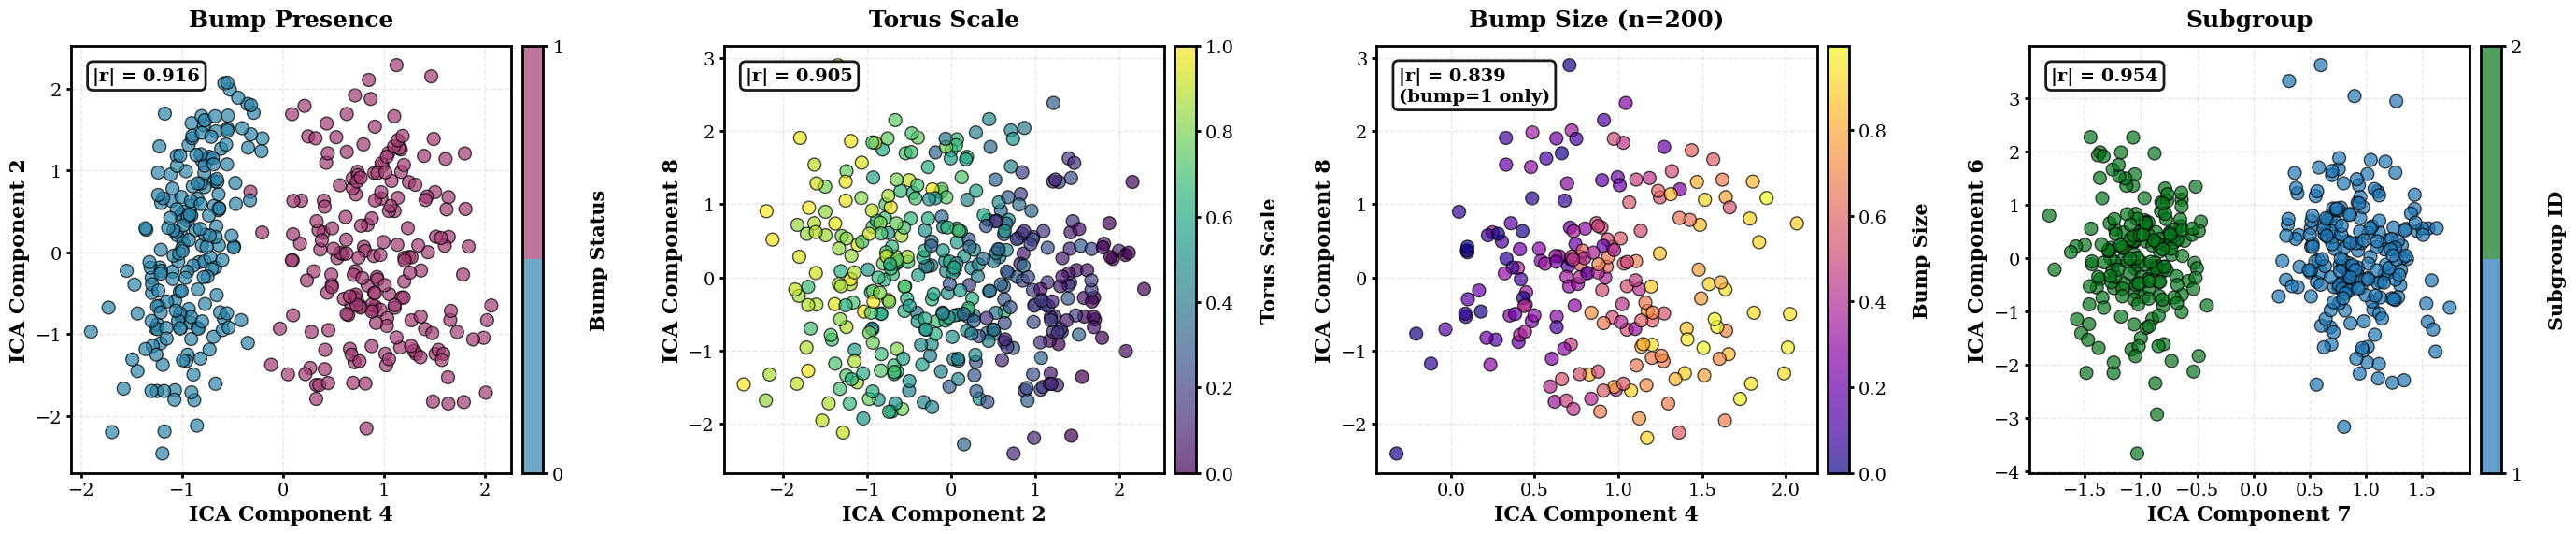

In [18]:
# Professional Publication-Ready Plots for ICA 8 Components
# Version 1: Single row layout (1x4)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes for each property (professional/standard schemes)
color_schemes = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),  # Blue (no bump), Red (bump)
        'label': 'Bump Status',  # Changed to match y-axis orientation
        'ticks': [0, 1],
        'tick_labels': ['No Bump', 'Bump']
    },
    'scales': {
        'cmap': 'viridis',
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',
        'label': 'Bump Size',  # Changed to match y-axis orientation
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': ListedColormap(['#1f77b4', "#06771C"]),  # Only 2 colors for 2 subgroups
        'label': 'Subgroup ID',
        'ticks': None,
        'tick_labels': None
    }
}

# Find best components for each label
labels_for_plot = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Calculate best components for each label
best_components = {}
for label_name, label_data in labels_for_plot.items():
    correlations = []
    for comp_idx in range(8):
        if label_name == 'bump_sizes':
            if np.sum(has_bump == 1) > 1:
                corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                         label_data[has_bump == 1])[0, 1])
            else:
                corr = 0
        else:
            corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
        correlations.append(corr)
    
    best_comp = np.argmax(correlations)
    best_components[label_name] = {
        'component': best_comp,
        'correlation': correlations[best_comp]
    }

print("Best components selected for each property:")
for label, info in best_components.items():
    print(f"  {label}: Component {info['component']+1} (|corr| = {info['correlation']:.4f})")

# VERSION 1: Single row layout (1x4)
fig, axes = plt.subplots(1, 4, figsize=(28, 6))
#fig.suptitle('ICA Latent Space Analysis: Factor Disentanglement', 
             #fontsize=22, fontweight='bold', y=1.02)

# Plot each property
for idx, (label_name, label_data) in enumerate(labels_for_plot.items()):
    ax = axes[idx]
    
    # Get best component for this label
    comp_x = best_components[label_name]['component']
    
    # Find second-best component
    correlations = []
    for comp_idx in range(8):
        if comp_idx == comp_x:
            correlations.append(-1)
        else:
            if label_name == 'bump_sizes':
                if np.sum(has_bump == 1) > 1:
                    corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                             label_data[has_bump == 1])[0, 1])
                else:
                    corr = 0
            else:
                corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
            correlations.append(corr)
    
    comp_y = np.argmax(correlations)
    
    # Get color scheme
    cmap = color_schemes[label_name]['cmap']
    
    # Filter data for bump_sizes: only plot points where has_bump == 1
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        x_data = Y_ica_8[mask, comp_x]
        y_data = Y_ica_8[mask, comp_y]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        x_data = Y_ica_8[:, comp_x]
        y_data = Y_ica_8[:, comp_y]
        color_data = label_data
        n_samples = len(label_data)
    
    # Create scatter plot
    scatter = ax.scatter(x_data, y_data,
                        c=color_data, cmap=cmap, 
                        s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
    
    # Set labels
    ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
    ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
    
    # Add sample count for bump_sizes
    if label_name == 'bump_sizes':
        title = f"Bump Size (n={n_samples})"
    elif label_name == 'has_bump':
        title = "Bump Presence"
    elif label_name == 'scales':
        title = "Torus Scale"
    else:
        title = "Subgroup"
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    
    # Add colorbar with proper settings
    if label_name == 'has_bump':
        cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1], pad=0.02)
        cbar.ax.set_yticklabels(['0', '1'], fontsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    elif label_name == 'subgroups':
        unique_subgroups = np.unique(subgroups)
        cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    else:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    
    # Add correlation annotation
    corr_text = f'|r| = {best_components[label_name]["correlation"]:.3f}'
    if label_name == 'bump_sizes':
        corr_text += f'\n(bump=1 only)'
    
    ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
           fontsize=14, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('ICA_factor_analysis_1x4.png', dpi=300, bbox_inches='tight')
plt.savefig('ICA_factor_analysis_1x4.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Version 1 (1x4) saved as 'ICA_factor_analysis_1x4.png' and '.pdf'")
plt.show()


✅ Version 2 (2x2) saved as 'ICA_factor_analysis_2x2.png' and '.pdf'


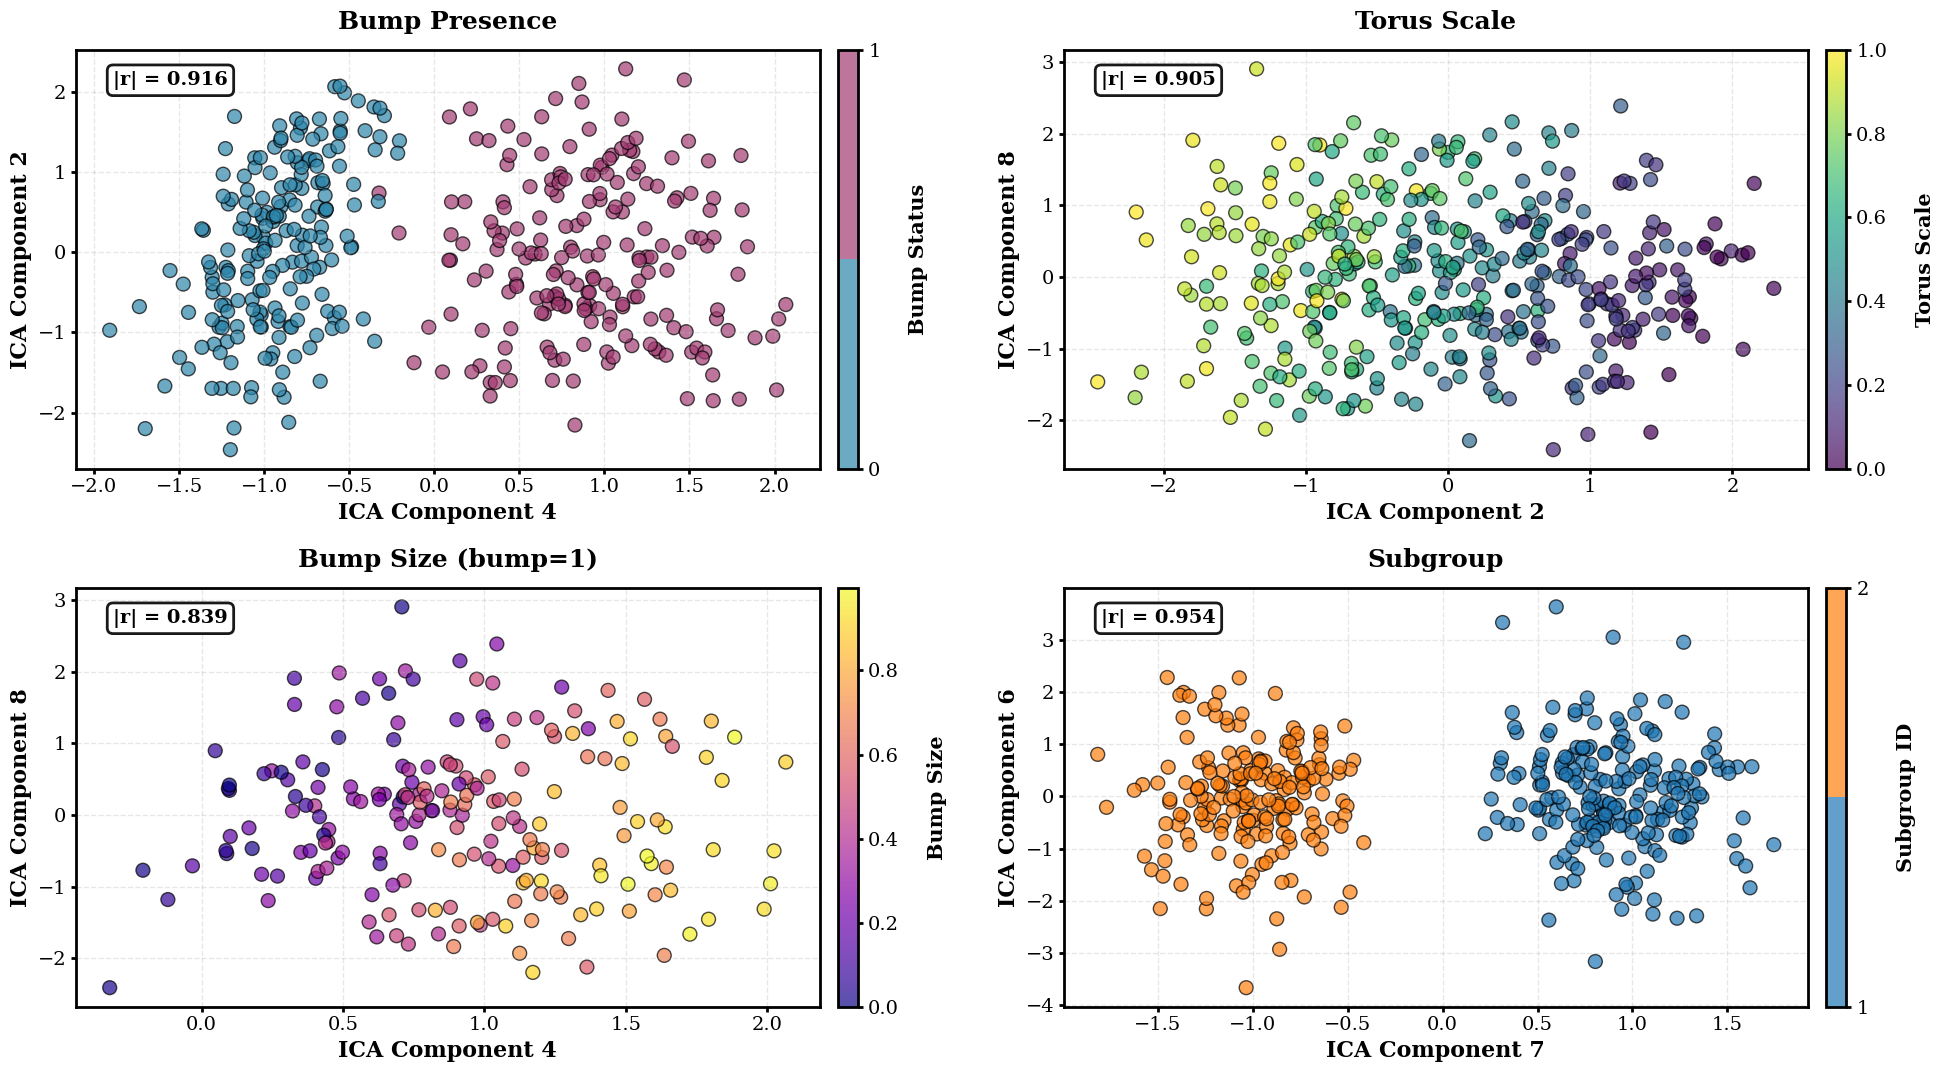


SUMMARY FOR DOCUMENTATION:

Bump Status:
  Primary Component: ICA Component 4
  Correlation: |r| = 0.9161

Torus Scale:
  Primary Component: ICA Component 2
  Correlation: |r| = 0.9054

Bump Size (bump=1 only):
  Primary Component: ICA Component 4
  Correlation: |r| = 0.8391
  Samples plotted: 200 (only where bump=1)

Subgroup ID:
  Primary Component: ICA Component 7
  Correlation: |r| = 0.9542


In [19]:
# Professional Publication-Ready Plots for ICA 8 Components
# Version 2: Two rows with reduced height (2x2)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes (same as Version 1)
color_schemes = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),
        'label': 'Bump Status',  # Changed to match orientation
        'ticks': [0, 1],
        'tick_labels': ['No Bump', 'Bump']
    },
    'scales': {
        'cmap': 'viridis',
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',
        'label': 'Bump Size',  # Changed to match orientation
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': ListedColormap(['#1f77b4', '#ff7f0e']),  # Only 2 colors
        'label': 'Subgroup ID',
        'ticks': None,
        'tick_labels': None
    }
}

# VERSION 2: Two rows with reduced height (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 11))  # Reduced height from 18 to 11
#fig.suptitle('ICA Latent Space Analysis: Factor Disentanglement', 
             #fontsize=22, fontweight='bold', y=0.995)

# Flatten axes
axes = axes.flatten()

# Plot each property
for idx, (label_name, label_data) in enumerate(labels_for_plot.items()):
    ax = axes[idx]
    
    # Get best component for this label
    comp_x = best_components[label_name]['component']
    
    # Find second-best component
    correlations = []
    for comp_idx in range(8):
        if comp_idx == comp_x:
            correlations.append(-1)
        else:
            if label_name == 'bump_sizes':
                if np.sum(has_bump == 1) > 1:
                    corr = np.abs(np.corrcoef(Y_ica_8[has_bump == 1, comp_idx], 
                                             label_data[has_bump == 1])[0, 1])
                else:
                    corr = 0
            else:
                corr = np.abs(np.corrcoef(Y_ica_8[:, comp_idx], label_data)[0, 1])
            correlations.append(corr)
    
    comp_y = np.argmax(correlations)
    
    # Get color scheme
    cmap = color_schemes[label_name]['cmap']
    
    # Filter data for bump_sizes
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        x_data = Y_ica_8[mask, comp_x]
        y_data = Y_ica_8[mask, comp_y]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        x_data = Y_ica_8[:, comp_x]
        y_data = Y_ica_8[:, comp_y]
        color_data = label_data
        n_samples = len(label_data)
    
    # Create scatter plot
    scatter = ax.scatter(x_data, y_data,
                        c=color_data, cmap=cmap, 
                        s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
    
    # Set labels
    ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
    ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
    
    # Titles
    if label_name == 'bump_sizes':
        title = f"Bump Size (bump=1)"
    elif label_name == 'has_bump':
        title = "Bump Presence"
    elif label_name == 'scales':
        title = "Torus Scale"
    else:
        title = "Subgroup"
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
    
    # Add colorbar with reduced padding
    if label_name == 'has_bump':
        cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1], pad=0.02)
        cbar.ax.set_yticklabels(['0', '1'], fontsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    elif label_name == 'subgroups':
        unique_subgroups = np.unique(subgroups)
        cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    else:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.ax.tick_params(labelsize=14)
        cbar.set_label(color_schemes[label_name]['label'], 
                      rotation=-270, labelpad=20, fontweight='bold', fontsize=15)
    
    # Add correlation annotation
    corr_text = f'|r| = {best_components[label_name]["correlation"]:.3f}'
    #if label_name == 'bump_sizes':
        #corr_text += f'\n(bump=1 only)'
    
    ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
           fontsize=14, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                    edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('ICA_factor_analysis_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('ICA_factor_analysis_2x2.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Version 2 (2x2) saved as 'ICA_factor_analysis_2x2.png' and '.pdf'")
plt.show()

# Print summary
print("\n" + "="*70)
print("SUMMARY FOR DOCUMENTATION:")
print("="*70)
for label_name, info in best_components.items():
    suffix = " (bump=1 only)" if label_name == 'bump_sizes' else ""
    print(f"\n{color_schemes[label_name]['label']}{suffix}:")
    print(f"  Primary Component: ICA Component {info['component']+1}")
    print(f"  Correlation: |r| = {info['correlation']:.4f}")
    if label_name == 'bump_sizes':
        print(f"  Samples plotted: {np.sum(has_bump == 1)} (only where bump=1)")

In [20]:
# ICA with 4 components - correlation analysis with all labels

import numpy as np
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply ICA with exactly 4 components
print("Applying ICA with 4 components...")
ica_4 = FastICA(n_components=4, random_state=42, max_iter=2000, tol=1e-6)
Y_ica_4 = ica_4.fit_transform(X_scaled)

print(f"ICA 4-component shape: {Y_ica_4.shape}")
print("\n" + "="*70)
print("ICA 4-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS")
print("="*70)

# Create mask for samples with bumps
samples_with_bump = has_bump == 1
n_bump_samples = np.sum(samples_with_bump)
print(f"\nTotal samples: {len(has_bump)}")
print(f"Samples with bumps: {n_bump_samples}")
print(f"Samples without bumps: {len(has_bump) - n_bump_samples}")

# Define labels for correlation
labels_dict_4comp = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Correlation matrix: rows = components, columns = labels
correlation_matrix_4 = np.zeros((4, len(labels_dict_4comp)))
label_names_4 = list(labels_dict_4comp.keys())

# Calculate correlations for each component with each label
for comp_idx in range(4):
    print(f"\nComponent {comp_idx+1}:")
    for label_idx, (label_name, label_data) in enumerate(labels_dict_4comp.items()):
        # Special handling: ONLY bump_sizes is conditional on bump=1
        if label_name == 'bump_sizes':
            if n_bump_samples > 1:
                corr = np.corrcoef(Y_ica_4[samples_with_bump, comp_idx], 
                                  label_data[samples_with_bump])[0, 1]
                correlation_matrix_4[comp_idx, label_idx] = corr
                print(f"  Correlation with {label_name:12s} (bump=1 only, n={n_bump_samples}): {corr:+.4f}")
            else:
                correlation_matrix_4[comp_idx, label_idx] = 0.0
                print(f"  Correlation with {label_name:12s}: N/A (insufficient samples)")
        else:
            # Regular correlation for has_bump, scales, and subgroups (use ALL samples)
            corr = np.corrcoef(Y_ica_4[:, comp_idx], label_data)[0, 1]
            correlation_matrix_4[comp_idx, label_idx] = corr
            print(f"  Correlation with {label_name:12s}: {corr:+.4f}")

# Find best component for each label
print("\n" + "="*70)
print("BEST COMPONENT FOR EACH LABEL:")
print("="*70)
for label_idx, label_name in enumerate(label_names_4):
    abs_corrs = np.abs(correlation_matrix_4[:, label_idx])
    best_comp = np.argmax(abs_corrs)
    best_corr = correlation_matrix_4[best_comp, label_idx]
    
    if label_name == 'bump_sizes':
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f}) [bump=1 only]")
    else:
        print(f"{label_name:12s}: Component {best_comp+1} (corr = {best_corr:+.4f}, |corr| = {abs_corrs[best_comp]:.4f})")

# Store results
results["ICA_4"] = Y_ica_4
transformed_latents["ICA_4"] = Y_ica_4

print("\n✅ ICA with 4 components completed!")
print(f"✅ Results stored in results['ICA_4'] and transformed_latents['ICA_4']")
print(f"✅ Correlation analysis completed!")
print(f"   - has_bump, scales & subgroups: ALL samples")
print(f"   - bump_sizes: ONLY bump=1 samples")

Applying ICA with 4 components...
ICA 4-component shape: (400, 4)

ICA 4-COMPONENT CORRELATION ANALYSIS WITH ALL LABELS

Total samples: 400
Samples with bumps: 200
Samples without bumps: 200

Component 1:
  Correlation with has_bump    : -0.0612
  Correlation with scales      : +0.1122
  Correlation with bump_sizes   (bump=1 only, n=200): +0.0041
  Correlation with subgroups   : -0.0003

Component 2:
  Correlation with has_bump    : +0.1182
  Correlation with scales      : +0.9103
  Correlation with bump_sizes   (bump=1 only, n=200): -0.0051
  Correlation with subgroups   : +0.0107

Component 3:
  Correlation with has_bump    : +0.8745
  Correlation with scales      : +0.0191
  Correlation with bump_sizes   (bump=1 only, n=200): +0.8525
  Correlation with subgroups   : +0.0163

Component 4:
  Correlation with has_bump    : +0.0015
  Correlation with scales      : -0.0139
  Correlation with bump_sizes   (bump=1 only, n=200): -0.1353
  Correlation with subgroups   : -0.9480

BEST COMPONE

Plotting all 6 pairwise combinations:
  Pair 1: Component 1 vs Component 2
  Pair 2: Component 1 vs Component 3
  Pair 3: Component 1 vs Component 4
  Pair 4: Component 2 vs Component 3
  Pair 5: Component 2 vs Component 4
  Pair 6: Component 3 vs Component 4

✅ Saved has_bump plots as 'ICA_4comp_all_pairs_has_bump.png' and '.pdf'


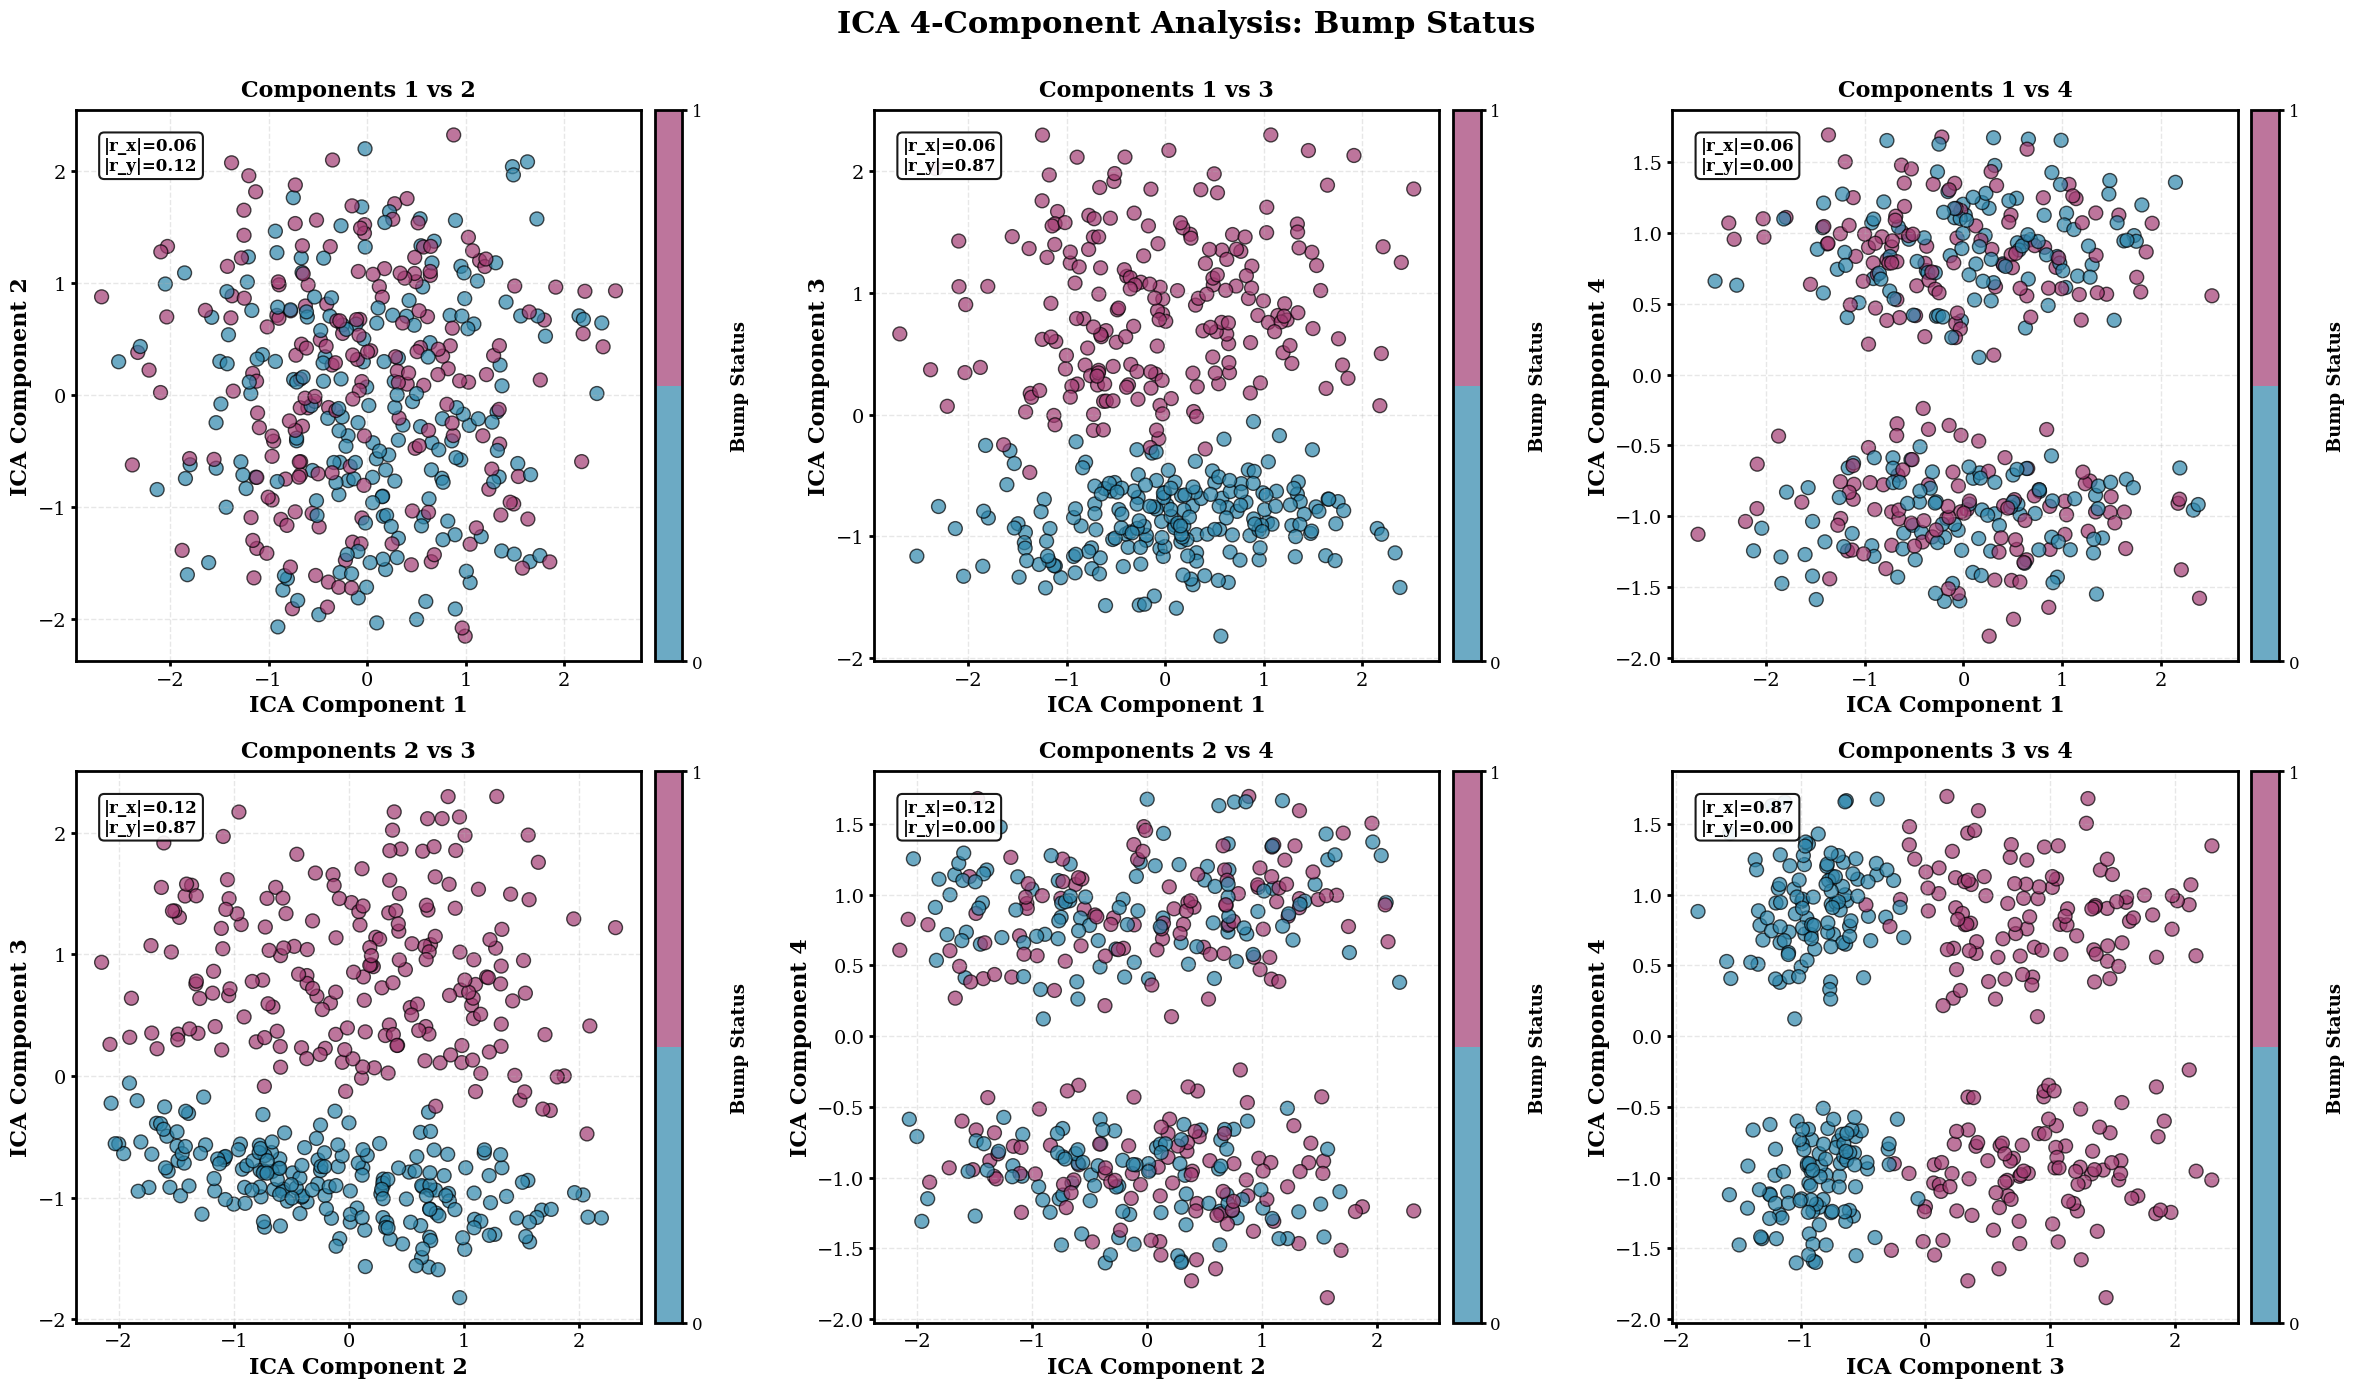


✅ Saved scales plots as 'ICA_4comp_all_pairs_scales.png' and '.pdf'


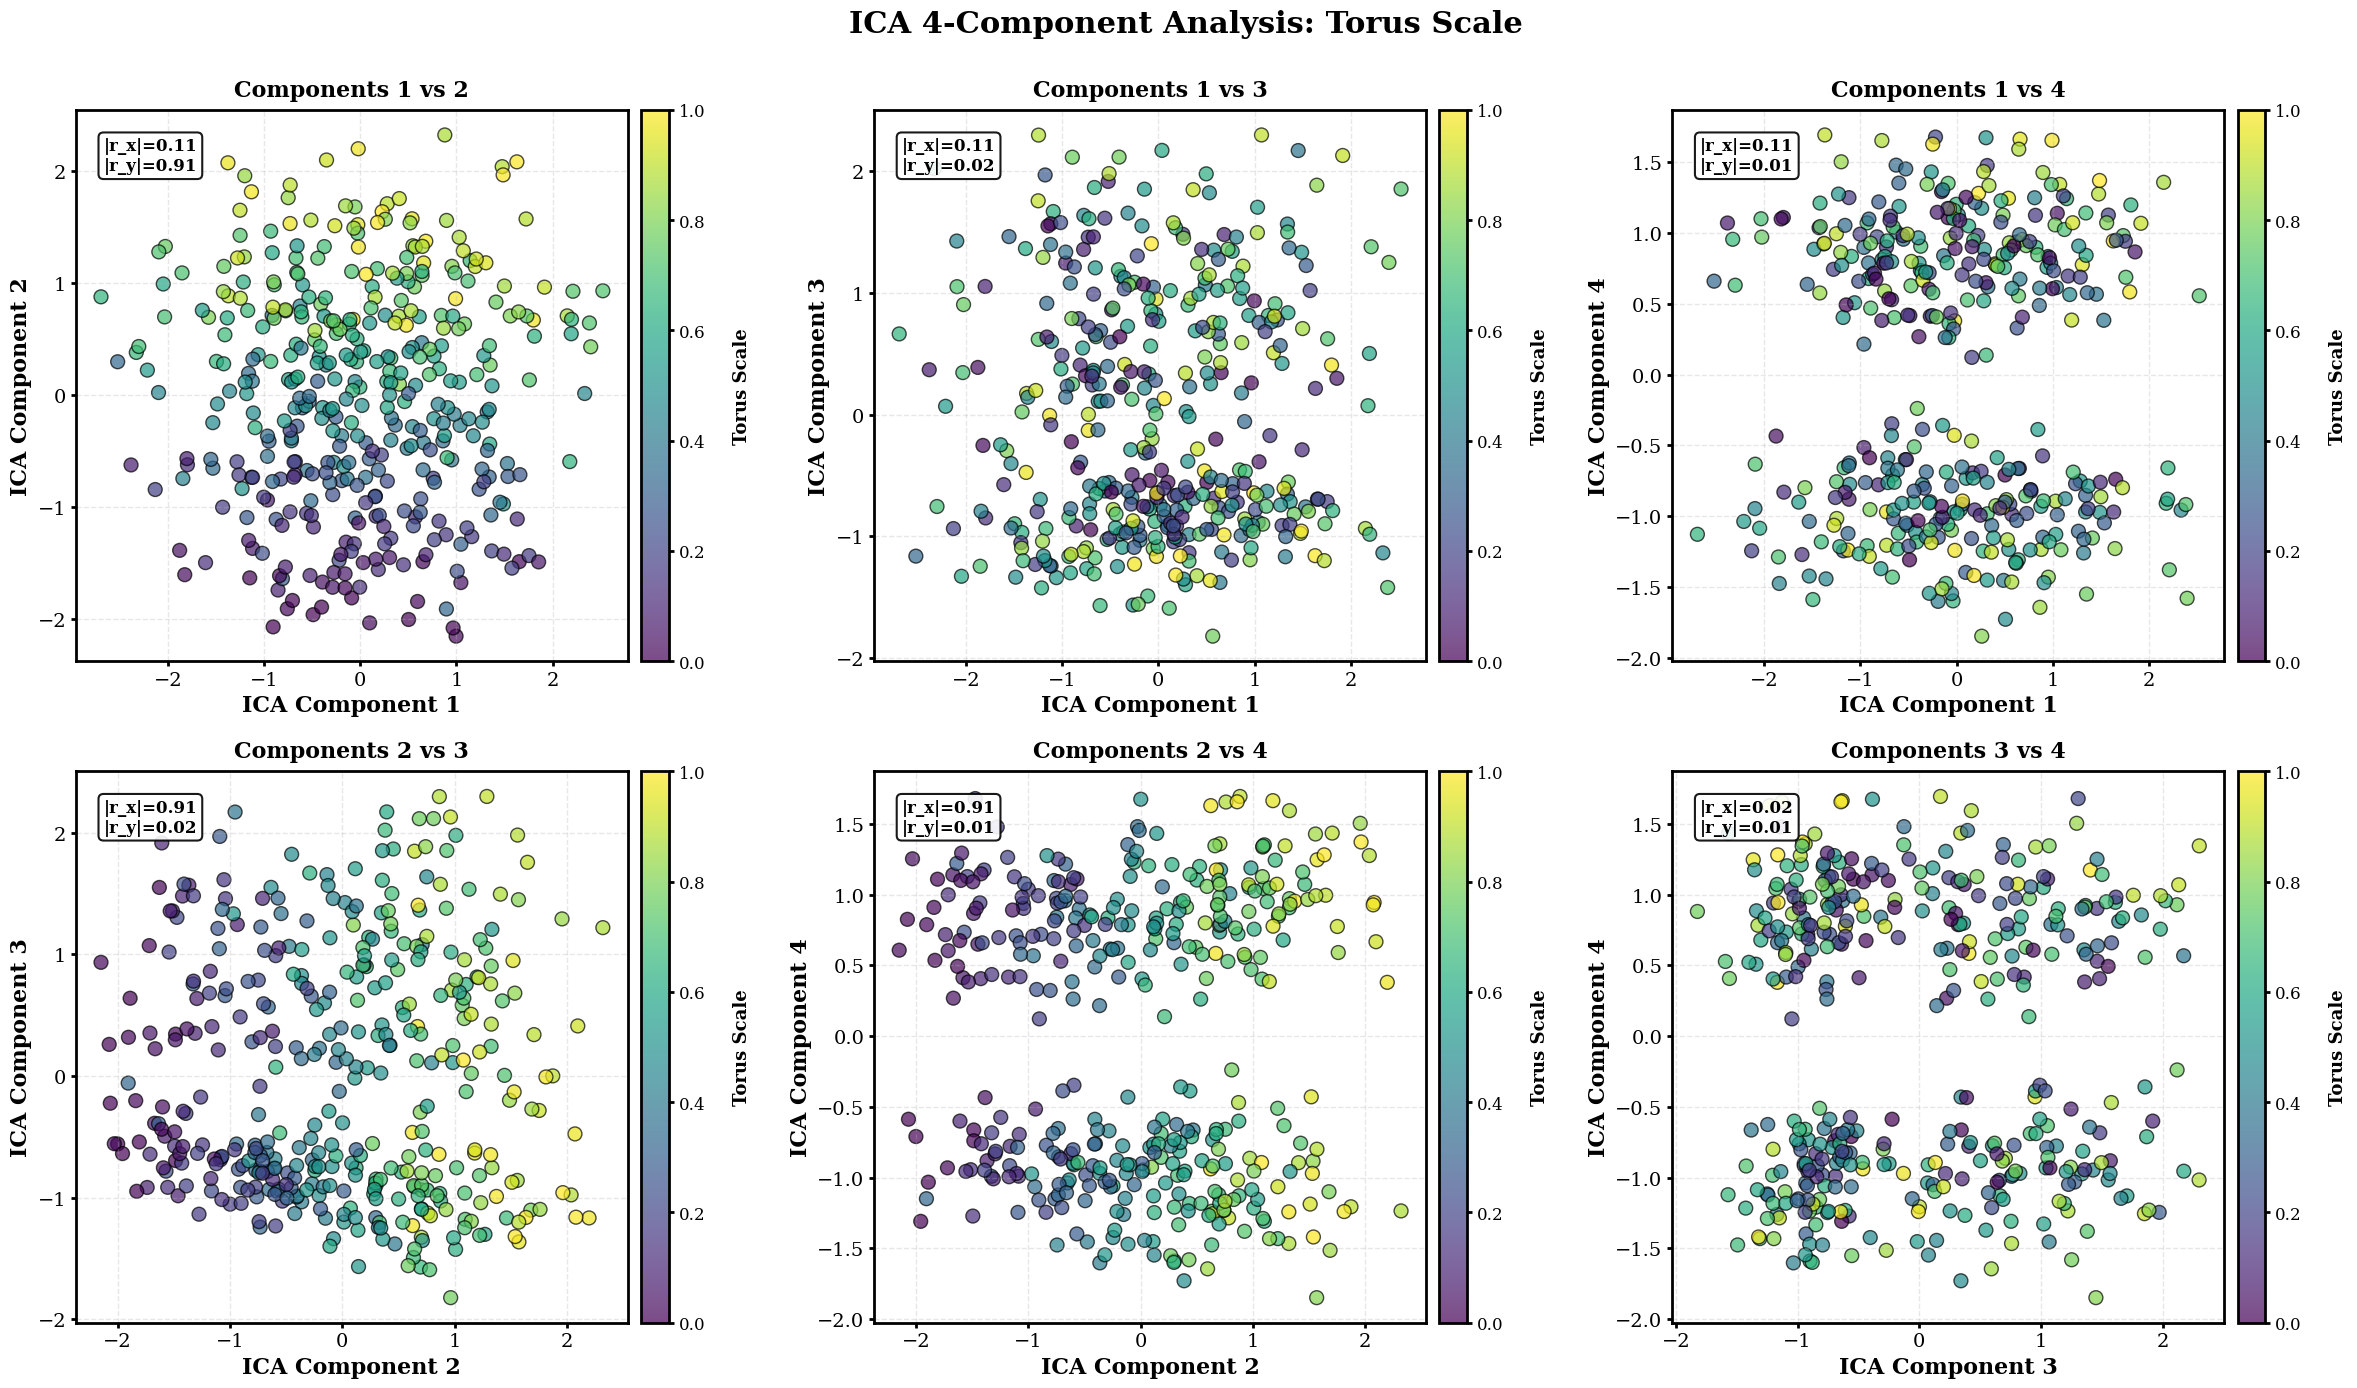


✅ Saved bump_sizes plots as 'ICA_4comp_all_pairs_bump_sizes.png' and '.pdf'


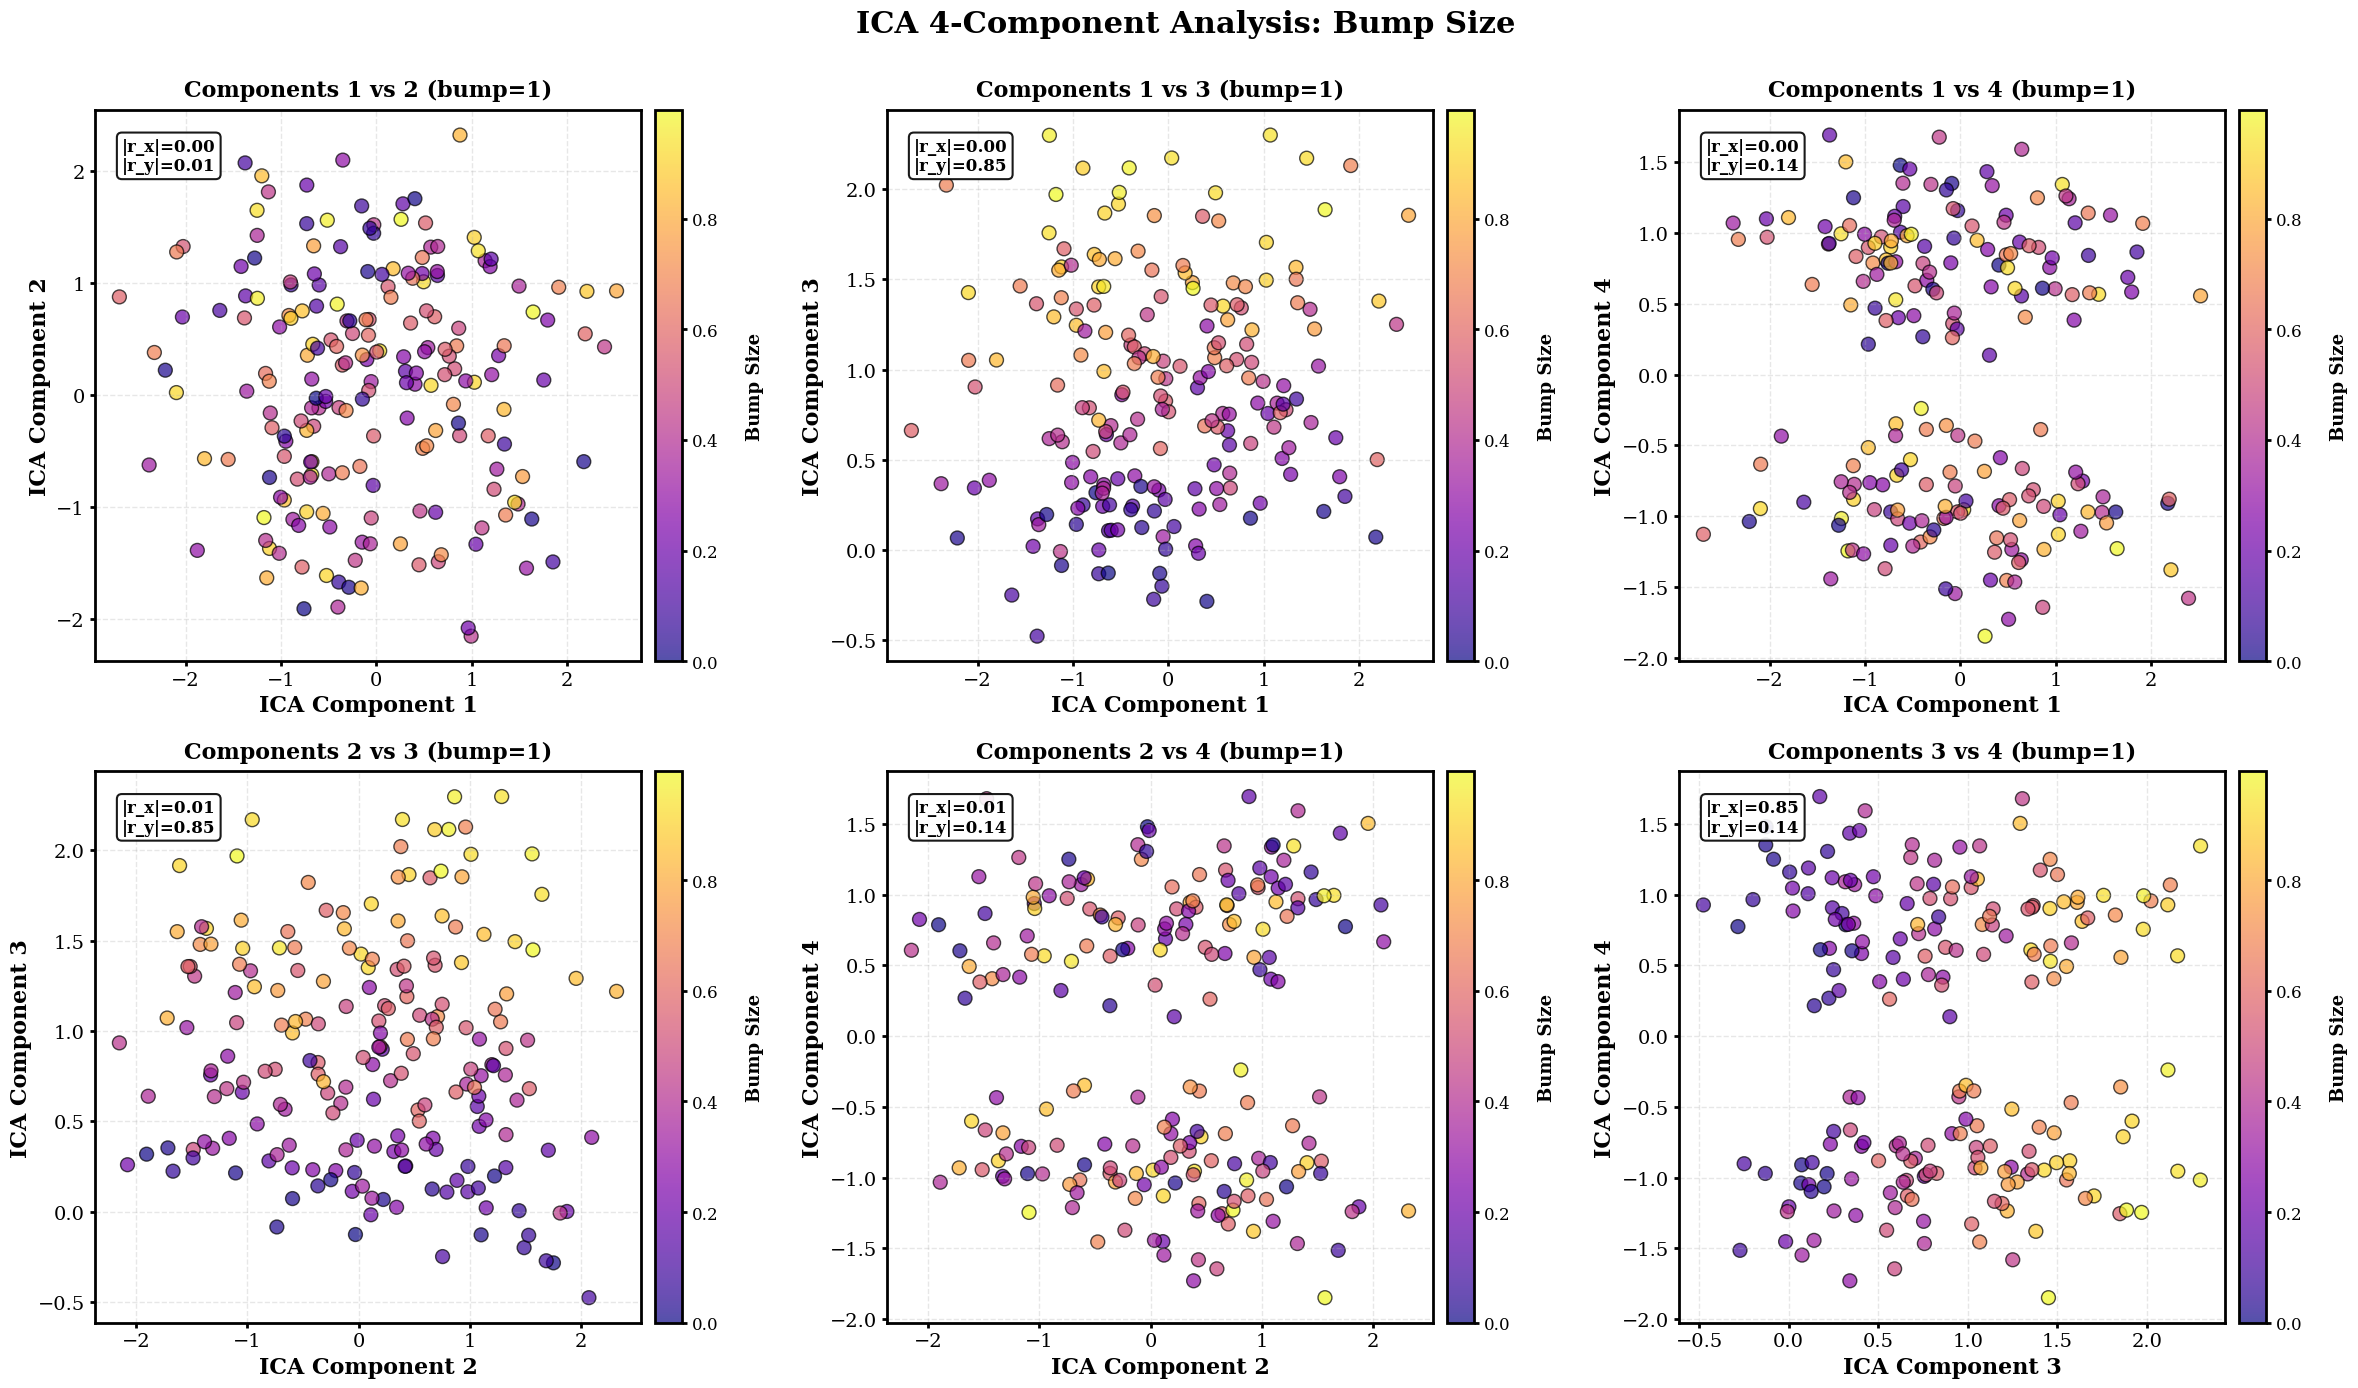


✅ Saved subgroups plots as 'ICA_4comp_all_pairs_subgroups.png' and '.pdf'


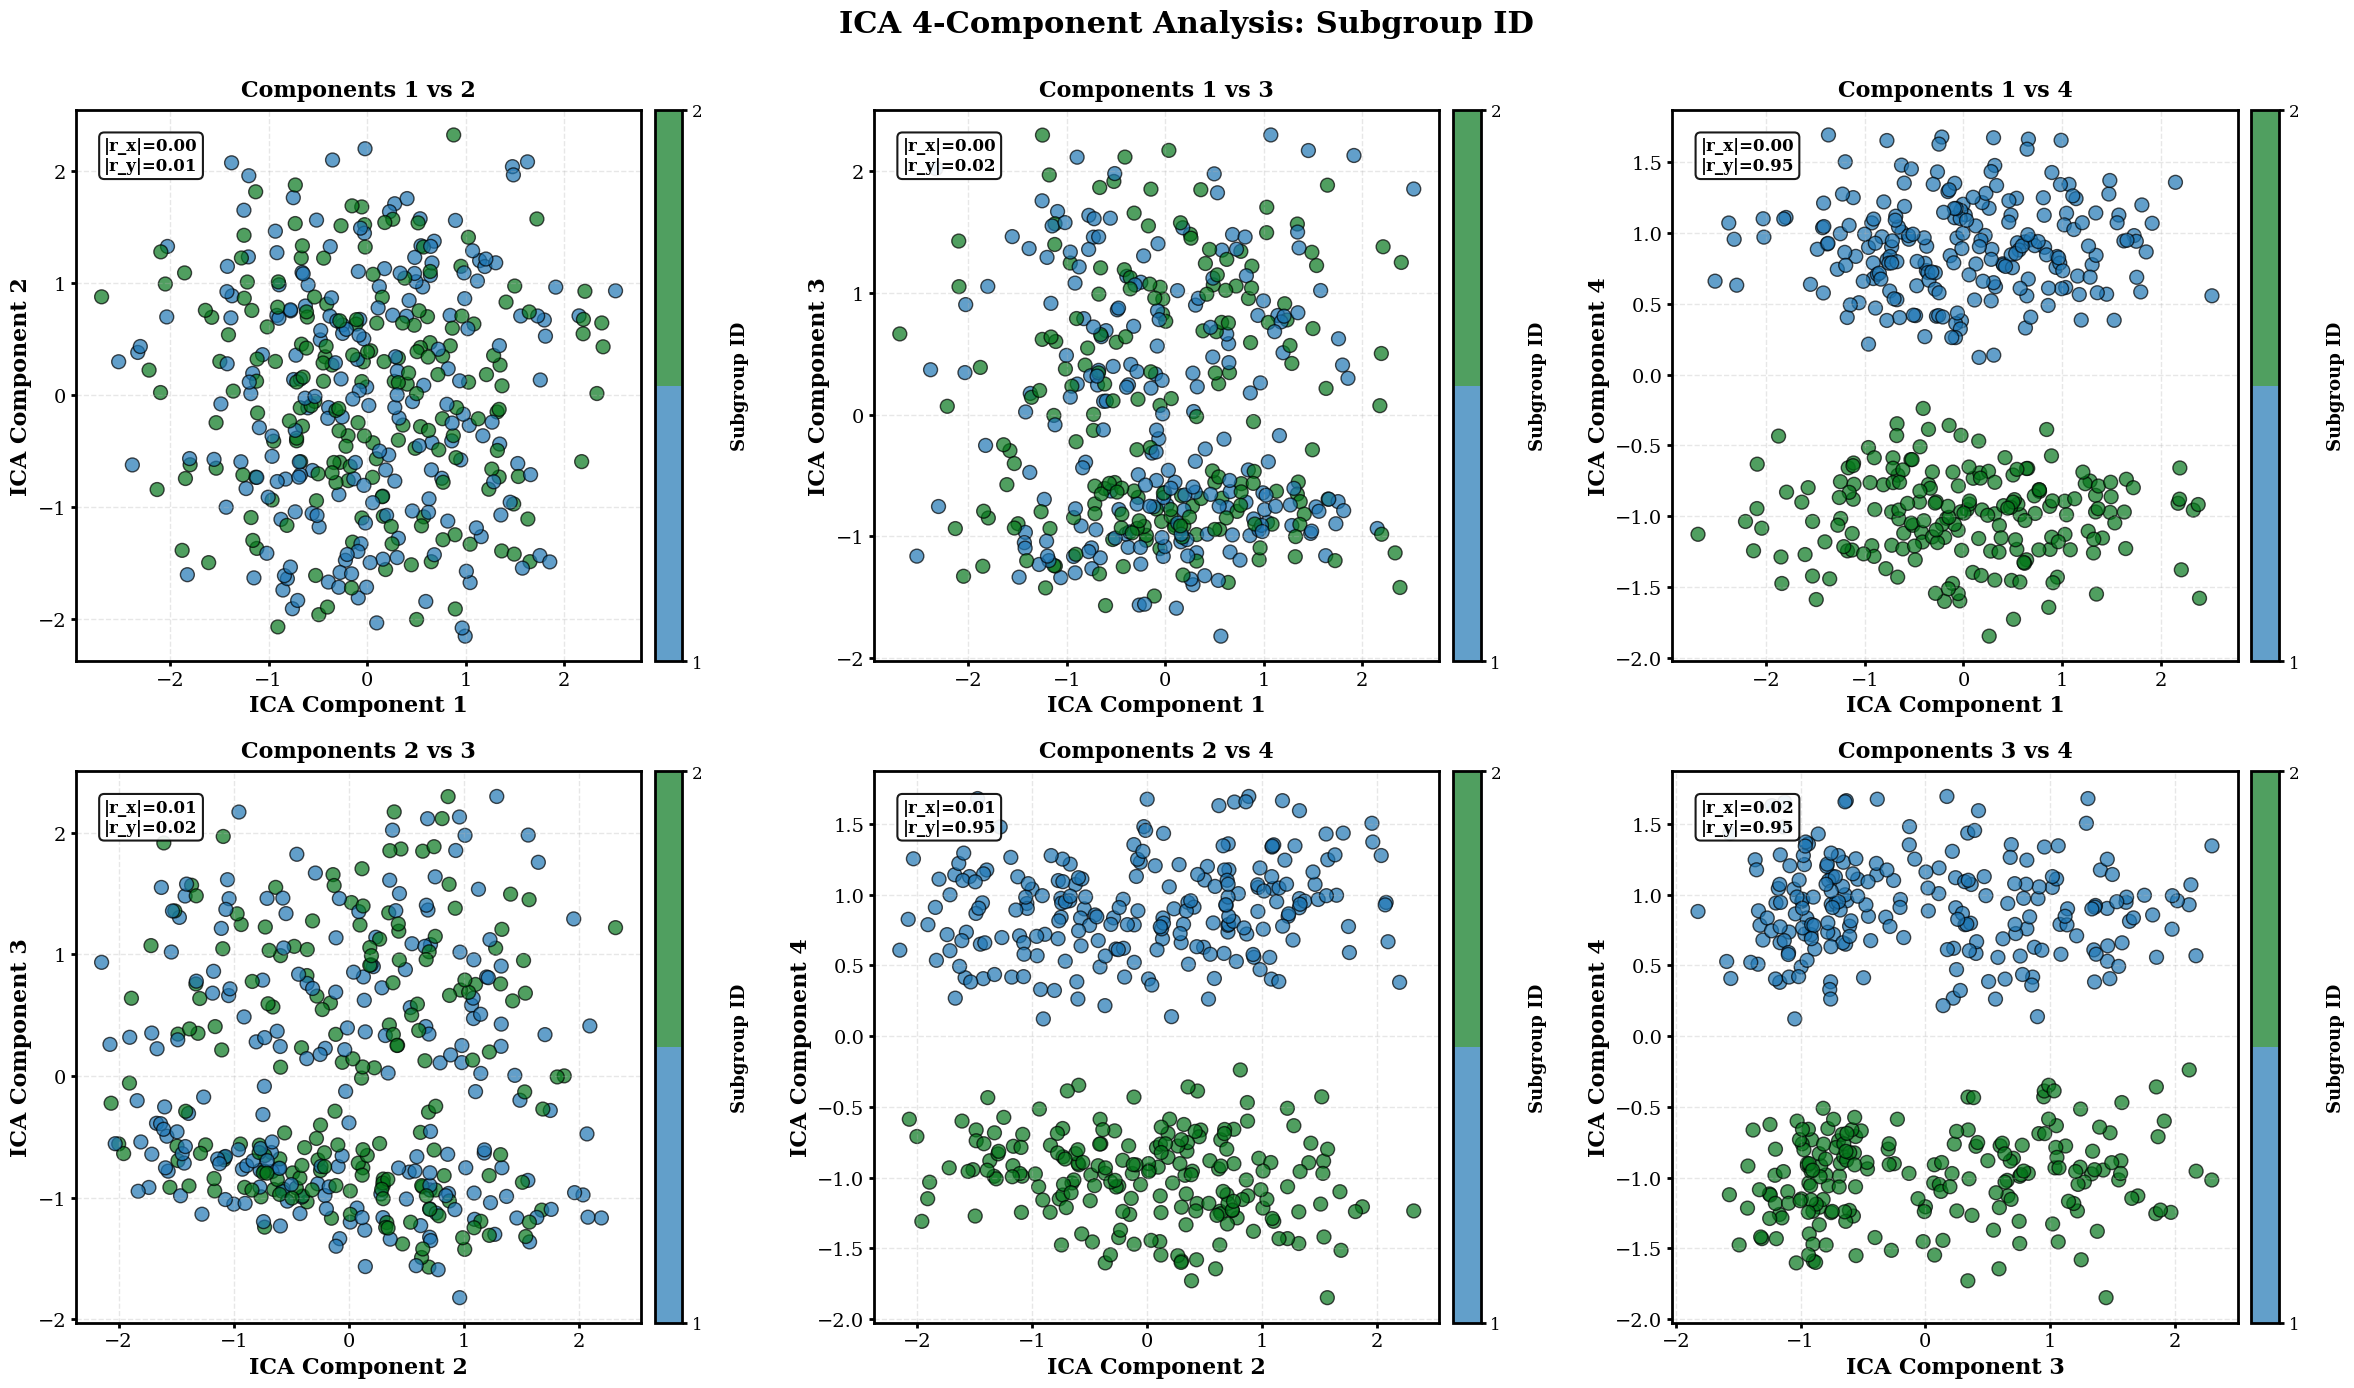


✅ All 4-component pairwise visualizations completed!
✅ Generated 4 figures (one per property), each with 6 component pairs


In [21]:
# Professional Publication-Ready Plots for ICA 4 Components
# All 6 pairwise combinations: (C1,C2), (C1,C3), (C1,C4), (C2,C3), (C2,C4), (C3,C4)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import itertools

# Set publication-quality style with LARGER fonts
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 2.0
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Define color schemes for each property
color_schemes_4 = {
    'has_bump': {
        'cmap': ListedColormap(['#2E86AB', '#A23B72']),
        'label': 'Bump Status',
        'ticks': [0, 1],
        'tick_labels': ['0', '1']
    },
    'scales': {
        'cmap': 'viridis',
        'label': 'Torus Scale',
        'ticks': None,
        'tick_labels': None
    },
    'bump_sizes': {
        'cmap': 'plasma',
        'label': 'Bump Size',
        'ticks': None,
        'tick_labels': None
    },
    'subgroups': {
        'cmap': ListedColormap(['#1f77b4', '#06771C']),
        'label': 'Subgroup ID',
        'ticks': None,
        'tick_labels': None
    }
}

labels_for_plot_4 = {
    'has_bump': has_bump,
    'scales': scales,
    'bump_sizes': bump_sizes,
    'subgroups': subgroups
}

# Generate all 6 pairwise combinations of 4 components
component_pairs = list(itertools.combinations(range(4), 2))
print(f"Plotting all {len(component_pairs)} pairwise combinations:")
for i, (c1, c2) in enumerate(component_pairs):
    print(f"  Pair {i+1}: Component {c1+1} vs Component {c2+1}")

# Create figure with 2 rows x 3 columns for 6 plots (one for each property x component pair)
n_properties = len(labels_for_plot_4)
n_pairs = len(component_pairs)

# We'll create 4 separate figures, one for each property, showing all 6 component pairs
for label_name, label_data in labels_for_plot_4.items():
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    fig.suptitle(f'ICA 4-Component Analysis: {color_schemes_4[label_name]["label"]}', 
                 fontsize=22, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    # Get color scheme for this property
    cmap = color_schemes_4[label_name]['cmap']
    
    # Filter data for bump_sizes: only plot points where has_bump == 1
    if label_name == 'bump_sizes':
        mask = has_bump == 1
        data_to_plot = Y_ica_4[mask, :]
        color_data = label_data[mask]
        n_samples = np.sum(mask)
    else:
        data_to_plot = Y_ica_4
        color_data = label_data
        n_samples = len(label_data)
    
    # Plot each component pair
    for pair_idx, (comp_x, comp_y) in enumerate(component_pairs):
        ax = axes[pair_idx]
        
        x_data = data_to_plot[:, comp_x]
        y_data = data_to_plot[:, comp_y]
        
        # Create scatter plot
        scatter = ax.scatter(x_data, y_data,
                            c=color_data, cmap=cmap, 
                            s=100, alpha=0.7, edgecolors='black', linewidths=1.0)
        
        # Set labels
        ax.set_xlabel(f'ICA Component {comp_x+1}', fontsize=16, fontweight='bold')
        ax.set_ylabel(f'ICA Component {comp_y+1}', fontsize=16, fontweight='bold')
        
        # Title
        if label_name == 'bump_sizes':
            title = f"Components {comp_x+1} vs {comp_y+1} (bump=1)"
        else:
            title = f"Components {comp_x+1} vs {comp_y+1}"
        
        ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=1.0)
        
        # Add colorbar
        if label_name == 'has_bump':
            cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1], pad=0.02)
            cbar.ax.set_yticklabels(['0', '1'], fontsize=12)
            cbar.set_label(color_schemes_4[label_name]['label'], 
                          rotation=-270, labelpad=20, fontweight='bold', fontsize=13)
        elif label_name == 'subgroups':
            unique_subgroups = np.unique(subgroups)
            cbar = plt.colorbar(scatter, ax=ax, ticks=unique_subgroups, pad=0.02)
            cbar.ax.tick_params(labelsize=12)
            cbar.set_label(color_schemes_4[label_name]['label'], 
                          rotation=-270, labelpad=20, fontweight='bold', fontsize=13)
        else:
            cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
            cbar.ax.tick_params(labelsize=12)
            cbar.set_label(color_schemes_4[label_name]['label'], 
                          rotation=-270, labelpad=20, fontweight='bold', fontsize=13)
        
        # Calculate correlation for this component pair with the label
        corr_x = np.corrcoef(x_data, color_data)[0, 1]
        corr_y = np.corrcoef(y_data, color_data)[0, 1]
        
        # Add correlation annotation
        corr_text = f'|r_x|={np.abs(corr_x):.2f}\n|r_y|={np.abs(corr_y):.2f}'
        ax.text(0.05, 0.95, corr_text, transform=ax.transAxes,
               fontsize=12, verticalalignment='top', fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                        edgecolor='black', linewidth=1.5))
    
    plt.tight_layout()
    filename_base = f'ICA_4comp_all_pairs_{label_name}'
    plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{filename_base}.pdf', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved {label_name} plots as '{filename_base}.png' and '.pdf'")
    plt.show()

print("\n✅ All 4-component pairwise visualizations completed!")
print(f"✅ Generated 4 figures (one per property), each with 6 component pairs")